In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1. Data Preparation:**

- Download the “Heart Disease UCI” dataset.

In [2]:
heart_disease = pd.read_csv("heart_disease_uci.csv")
heart_disease.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df = heart_disease.copy()

- Perform exploratory data analysis (EDA) to understand the dataset.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
# Verify the target variable
df['num'].unique()

array([0, 2, 1, 3, 4])

-> It's a multiclass classification (different levels of heart disease severity).

- Preprocess the data: handle missing values if any, encode categorical variables, and scale the features.

In [6]:
# Missing values
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [7]:
# Total rows/colomns
df.shape

(920, 16)

In [8]:
# There are only 2 missing values in column 'restecg'
# We can remove them
df.dropna(subset=['restecg'], inplace=True)
df.shape

(918, 16)

In [9]:
missing_percentage = df[['ca', 'thal']].isna().sum() / len(df) * 100
print(missing_percentage)

ca      66.339869
thal    52.723312
dtype: float64


In [10]:
# Both columns have more than 50% missing values, so it may be better
# to drop them instead of filling them
df.drop(columns=['ca', 'thal'], inplace=True)
df.shape

(918, 14)

In [11]:
# Fill numeric columns with median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

# Fill binary/categorical columns with mode
df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])
df['exang'] = df['exang'].fillna(df['exang'].mode()[0])
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])

df.isnull().sum()

<ipython-input-11-210adeebbd70>:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
<ipython-input-11-210adeebbd70>:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].fillna(df['exang'].mode()[0])


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        918 non-null    int64  
 1   age       918 non-null    int64  
 2   sex       918 non-null    object 
 3   dataset   918 non-null    object 
 4   cp        918 non-null    object 
 5   trestbps  918 non-null    float64
 6   chol      918 non-null    float64
 7   fbs       918 non-null    bool   
 8   restecg   918 non-null    object 
 9   thalch    918 non-null    float64
 10  exang     918 non-null    bool   
 11  oldpeak   918 non-null    float64
 12  slope     918 non-null    object 
 13  num       918 non-null    int64  
dtypes: bool(2), float64(4), int64(3), object(5)
memory usage: 95.0+ KB


In [13]:
df['cp'].unique()

array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object)

In [14]:
# Encode categorical variables

# Binary categorical
df['sex'] = df['sex'].map({'Male': 0, 'Female': 1})
df['fbs'] = df['fbs'].astype(int) # True → 1, False → 0
df['exang'] = df['exang'].astype(int)

# Categorical with few unique values (it has an order)
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['restecg'] = encoder.fit_transform(df['restecg']) # ['lv hypertrophy', 'normal', 'st-t abnormality']
# Print category-to-number mapping
restecg_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("restecg Mapping:", restecg_mapping)

df['slope'] = encoder.fit_transform(df['slope']) # ['downsloping', 'flat', 'upsloping']
# Print category-to-number mapping
slope_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("slope Mapping:", slope_mapping)

# Categorical with many unique values (Nominal, No order)
df = pd.get_dummies(df, columns=['dataset','cp'])


restecg Mapping: {'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}
slope Mapping: {'downsloping': 0, 'flat': 1, 'upsloping': 2}


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     918 non-null    int64  
 1   age                    918 non-null    int64  
 2   sex                    918 non-null    int64  
 3   trestbps               918 non-null    float64
 4   chol                   918 non-null    float64
 5   fbs                    918 non-null    int64  
 6   restecg                918 non-null    int64  
 7   thalch                 918 non-null    float64
 8   exang                  918 non-null    int64  
 9   oldpeak                918 non-null    float64
 10  slope                  918 non-null    int64  
 11  num                    918 non-null    int64  
 12  dataset_Cleveland      918 non-null    bool   
 13  dataset_Hungary        918 non-null    bool   
 14  dataset_Switzerland    918 non-null    bool   
 15  dataset_VA 

In [16]:
# Feature scaling (on numerical)
from sklearn.preprocessing import StandardScaler

features_to_scale = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

df.head()

,id,age,sex,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
0,1,1.006574,0,0.704276,0.302947,1,0,0.489941,0,1.365839,0,0,True,False,False,False,False,False,False,True
1,2,1.431759,0,1.517244,0.789835,0,0,-1.179833,1,0.609717,1,2,True,False,False,False,True,False,False,False
2,3,1.431759,0,-0.650669,0.266200,0,0,-0.344946,1,1.649385,1,1,True,False,False,False,True,False,False,False
3,4,-1.757133,0,-0.108691,0.459118,0,1,1.960932,0,2.500024,0,0,True,False,False,False,False,False,True,False
4,5,-1.331947,1,-0.108691,0.036536,0,0,1.364584,0,0.515201,2,0,True,False,False,False,False,True,False,False


In [17]:
df.describe()

,id,age,sex,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
count,918.000000,9.180000e+02,918.000000,9.180000e+02,918.000000,918.000000,918.000000,9.180000e+02,918.000000,9.180000e+02,918.000000,918.000000
mean,460.227669,2.476837e-16,0.211329,-4.063561e-16,0.000000,0.150327,0.990196,-4.024861e-16,0.367102,2.322035e-17,1.151416,0.995643
std,265.950093,1.000545e+00,0.408474,1.000545e+00,1.000545,0.357586,0.632552,1.000545e+00,0.482278,1.000545e+00,0.515785,1.143939
min,1.000000,-2.713801e+00,0.000000,-7.154406e+00,-1.837524,0.000000,0.000000,-3.088147e+00,0.000000,-3.265413e+00,0.000000,0.000000
25%,230.250000,-6.941689e-01,0.000000,-6.506689e-01,-0.200018,0.000000,1.000000,-7.027551e-01,0.000000,-8.080136e-01,1.000000,0.000000
50%,459.500000,4.990605e-02,0.000000,-1.086908e-01,0.211081,0.000000,1.000000,9.237546e-02,0.000000,-3.354368e-01,1.000000,1.000000
75%,690.750000,6.876845e-01,0.000000,4.332873e-01,0.612993,0.000000,1.000000,7.284799e-01,1.000000,6.097166e-01,1.000000,2.000000
max,920.000000,2.494724e+00,1.000000,3.685156e+00,3.701978,1.000000,2.000000,2.557280e+00,1.000000,5.051938e+00,2.000000,4.000000


**2. Model Training:**

- Split the dataset into a training set and a testing set.

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['num'])
y = df['num'] # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


- Train a logistic regression model on the training set.

In [19]:
from sklearn.linear_model import LogisticRegression

# Create and train the logistic regression model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**3. Model Evaluation:**

- Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.

In [20]:
from math import log
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions
y_pred = log_model.predict(X_test)

# Accuracy
# how many predictions were correct compared to the total number of predictions.
log_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {log_accuracy:.2f}")

# Precision
# How Many of the Predicted Positives Are Correct
log_precision = precision_score(y_test, y_pred, average='weighted', zero_division=1) # average for multi-class classification
print(f"Precision: {log_precision:.2f}")

# Recall
# How Many of the Actual Positives Did We Find
log_recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {log_recall:.2f}")

# F1 Score
# The Balance Between Precision and Recall
log_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {log_f1:.2f}")

Accuracy: 0.52
Precision: 0.50
Recall: 0.52
F1 Score: 0.49


- Use a confusion matrix to visualize the model’s performance.


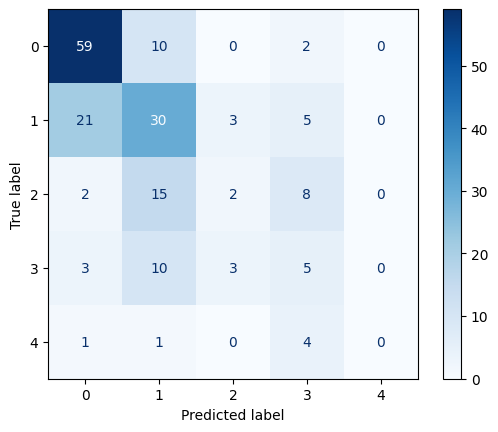

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=log_model.classes_)
disp.plot(cmap='Blues')
plt.show()


**Conclusion:**

- **Accuracy: 52%**
(How many predictions were correct compared to the total number of predictions)
 - The model correctly classified 52% of all tests samples, which is only slightly better than random guessing for a multi-class problem.

- **Precision: 50%**
(How Many of the Predicted Positives Are Correct)
 - The model frequently misclassifies certain class (eg. class 1 is often mistaken for class 0).
 - Class 4 is never predicted, which negatively affects precision.

- **Recall: 52%**
(How Many of the Actual Positives Did We Find)
 - Many actual cases are misclassified, meaning that some conditions (especially class 1 and 3) are not recognized well.

- **F1-Score: 49%**
(The Balance Between Precision and Recall)
 - The balance between precision and recall is weak, meaning the model struggles to differenciate between some classes.


The logistic regression model does not perform well to predict wether or not a patient has heart disease, especially for class 1 and 4. We could try different model, adjust class weights and improve feature engineering to obtain a better performance.